---
## 1. Setup & Import Library

In [1]:
!pip install squarify
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import squarify
from IPython.display import Markdown, display

---
## 2. Data Collection

The dataset consists of two sheets covering different time periods. Both are combined into a single dataframe before processing.

In [2]:
df_2009 = pd.read_excel("/content/online_retail_II.xlsx", sheet_name='Year 2009-2010')
df_2010 = pd.read_excel("/content/online_retail_II.xlsx", sheet_name='Year 2010-2011')

df = pd.concat([df_2009, df_2010], ignore_index=True)

In [3]:
print(f"New shape: {df.shape}")
print(f"Period: {df['InvoiceDate'].min().date()} s/d {df['InvoiceDate'].max().date()}")

New shape: (1067371, 8)
Period: 2009-12-01 s/d 2011-12-09


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


---
## 3. Data Understanding

Before cleaning the data, we need to understand its structure, data types, and potential issues.

In [5]:
display(df.head())

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [6]:
print("Missing values by column:")
print(df.isna().sum())

Missing values by column:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64


In [7]:
print(f"Number of unique customers (RAW, before cleaning): {df['Customer ID'].nunique():,}")
print(f"Count of cancelled invoice lines: {df['Invoice'].astype(str).str.startswith('C').sum():,}")

Number of unique customers (RAW, before cleaning): 5,942
Count of cancelled invoice lines: 19,494


---
## 4. Data Cleaning

In [8]:
n_raw = len(df)

In [9]:
df = df.dropna(subset=['Customer ID'])
print(f"After remove missing values in Customer ID : {len(df):,} rows (-{n_raw - len(df):,})")

After remove missing values in Customer ID : 824,364 rows (-243,007)


In [10]:
n_before = len(df)
df = df[~df['Invoice'].astype(str).str.startswith('C')]
print(f"After filtering cancelled invoice: {len(df):,} rows (-{n_before - len(df):,})")

After filtering cancelled invoice: 805,620 rows (-18,744)


In [11]:
n_before = len(df)
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]
print(f"After filtering Qty/Price <= 0  : {len(df):,} rows (-{n_before - len(df):,})")

After filtering Qty/Price <= 0  : 805,549 rows (-71)


In [12]:
print(f"Total rows after cleaning: {len(df):,} (from {n_raw:,} beginning)")
print(f"Unique customers after cleaning: {df['Customer ID'].nunique():,}")

Total rows after cleaning: 805,549 (from 1,067,371 beginning)
Unique customers after cleaning: 5,878


In [13]:
print(f"Unique country after cleaning: {df['Country'].nunique():,}")

Unique country after cleaning: 41


---
## 5. Exploratory Data Analysis (EDA)

Before diving into RFM, let’s explore the data distribution and macro business patterns.

In [14]:
df['TotalPrice'] = df['Quantity'] * df['Price']

In [15]:
total_revenue = df['TotalPrice'].sum()
print(f"Total Revenue: £{total_revenue:,.2f}")

Total Revenue: £17,743,429.18


In [16]:
total_transactions = df['Invoice'].nunique()
total_customers = df['Customer ID'].nunique()
total_revenue = df['TotalPrice'].sum()
average_transaction_value = total_revenue / total_transactions

markdown_table = f"""
### Transaction Analysis KPIs

| KPI                       | Value                             |
|:--------------------------|:------------------------          |
| Total Transactions        | {total_transactions:,}            |
| Total Customers           | {total_customers:,}               |
| Total Revenue             | £{total_revenue:,.2f}             |
| Average Transaction Value | £{average_transaction_value:,.2f} |
"""
display(Markdown(markdown_table))


### Transaction Analysis KPIs

| KPI                       | Value                             |
|:--------------------------|:------------------------          |
| Total Transactions        | 36,969            |
| Total Customers           | 5,878               |
| Total Revenue             | £17,743,429.18             |
| Average Transaction Value | £479.95 |


In [17]:
monthly_revenue = (df.assign(InvoiceMonth=df['InvoiceDate'].dt.to_period('M')).groupby('InvoiceMonth')['TotalPrice'].sum().reset_index())
monthly_revenue['InvoiceMonth'] = monthly_revenue['InvoiceMonth'].astype(str)

In [18]:
november_2010_data = df[(df['InvoiceDate'].dt.month == 11) & (df['InvoiceDate'].dt.year == 2010)]
product_sales_november_2010 = november_2010_data.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).reset_index()
print("Top 10 Products by Revenue in November 2010:")
display(product_sales_november_2010.head(10))

november_2011_data = df[(df['InvoiceDate'].dt.month == 11) & (df['InvoiceDate'].dt.year == 2011)]
product_sales_november_2011 = november_2011_data.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).reset_index()
print("\nTop 10 Products by Revenue in November 2011:")
display(product_sales_november_2011.head(10))

Top 10 Products by Revenue in November 2010:


,Description,TotalPrice
0,REGENCY CAKESTAND 3 TIER,22257.45
1,ROTATING SILVER ANGELS T-LIGHT HLDR,20569.50
2,WHITE HANGING HEART T-LIGHT HOLDER,17064.73
3,ASSORTED COLOUR BIRD ORNAMENT,14345.75
4,PAPER CHAIN KIT 50'S CHRISTMAS,13493.25
5,JUMBO BAG RED RETROSPOT,10682.85
6,PAPER CHAIN KIT VINTAGE CHRISTMAS,8246.65
7,POSTAGE,8112.90
8,HAND WARMER OWL DESIGN,7745.40
9,HOT WATER BOTTLE BABUSHKA,7465.35



Top 10 Products by Revenue in November 2011:


,Description,TotalPrice
0,RABBIT NIGHT LIGHT,23268.73
1,PAPER CHAIN KIT 50'S CHRISTMAS,16139.01
2,WHITE HANGING HEART T-LIGHT HOLDER,13855.83
3,REGENCY CAKESTAND 3 TIER,11064.24
4,JUMBO BAG RED RETROSPOT,10713.99
5,POSTAGE,10349.95
6,CHILLI LIGHTS,9792.83
7,HOT WATER BOTTLE KEEP CALM,9500.10
8,PAPER CHAIN KIT VINTAGE CHRISTMAS,8654.11
9,ASSORTED COLOUR BIRD ORNAMENT,8252.70


In [19]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')
customer_months = df.groupby('Customer ID')['Month'].apply(lambda x: list(x.astype(str).unique()))
nov_only = customer_months[customer_months.apply(lambda x: all('11' in m for m in x))]
print(f"Customers only buy in Nov: {len(nov_only)}")
print(f"From total: {df['Customer ID'].nunique()} customers")
print(f"Percentage: {len(nov_only)/df['Customer ID'].nunique()*100:.1f}%")

Customers only buy in Nov: 1804
From total: 5878 customers
Percentage: 30.7%


In [20]:
df['MonthNum'] = df['InvoiceDate'].dt.month
customer_months = df.groupby('Customer ID')['MonthNum'].apply(lambda x: list(x.unique()))
one_month_buyers = customer_months[customer_months.apply(lambda x: len(x) == 1)]
breakdown = one_month_buyers.apply(lambda x: x[0]).value_counts().sort_index()
breakdown.index = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

print(f"Total single-month buyers: {len(one_month_buyers)} ({len(one_month_buyers)/5878*100:.1f}%)")
print("\nBreakdown by month:")
print(breakdown.to_string())

Total single-month buyers: 1859 (31.6%)

Breakdown by month:
Jan     84
Feb    116
Mar    158
Apr    113
May    106
Jun    122
Jul     91
Aug     98
Sep    188
Oct    287
Nov    342
Dec    154


---
## 6. Feature Engineering - RFM Calculation

RFM is calculated at the customer level (by `Customer ID`) using a reference date of one day after the last transaction.

In [21]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
rfm = df.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency = ('Invoice',     'nunique'),
    Monetary  = ('TotalPrice',  'sum')
)

print("RFM descriptive statistics:")
print(rfm.describe().round(2).T)

RFM descriptive statistics:
            count     mean       std   min     25%     50%      75%        max
Recency    5878.0   201.33    209.34  1.00   26.00   96.00   380.00     739.00
Frequency  5878.0     6.29     13.01  1.00    1.00    3.00     7.00     398.00
Monetary   5878.0  3018.62  14737.73  2.95  348.76  898.92  2307.09  608821.65


### Repeat vs One-Time Customer Analysis

#### Customer Distribution


| Type                | Count        |
|:--------------------|:-------------|
| One-Time Customer   | 1,623 |
| Repeat Customer     | 4,255 |
| **Total Customers** | 5,878 |


#### Revenue Contribution


| Type                | Total Revenue   | Percentage |
|:--------------------|:----------------|:-----------|
| One-Time Customer   | £568,173.83 | 3.2%   |
| Repeat Customer     | £17,175,255.35 | 96.8%   |
| **Total Revenue**   | £17,743,429.18 | **100.0%** |


/tmp/ipykernel_2259/3078986702.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Type', y='Revenue', data=revenue_contribution, ax=axes[1], palette=['#d9d9d9', '#8b1a1a'], width=0.6)


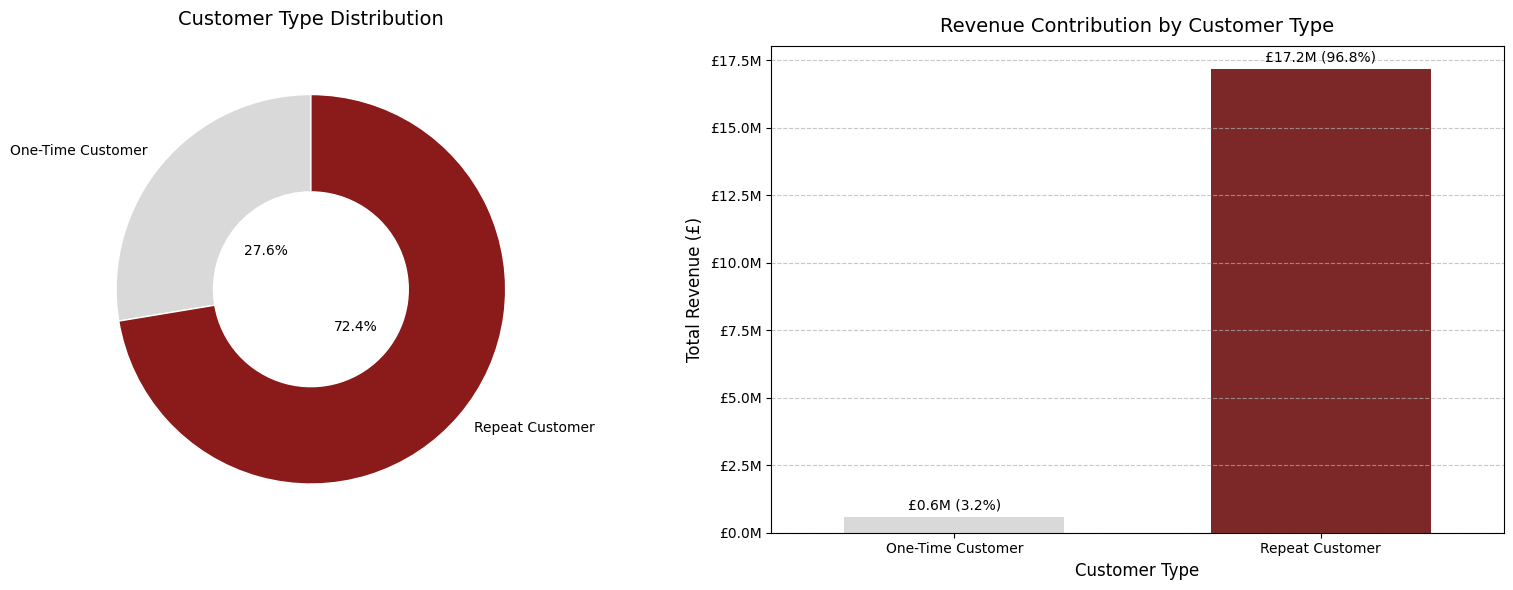

In [22]:
one_time_customers_count = rfm[rfm['Frequency'] == 1].shape[0]
repeat_customers_count = rfm[rfm['Frequency'] > 1].shape[0]
total_customers = rfm.shape[0]

one_time_customers_pct = (one_time_customers_count / total_customers) * 100
repeat_customers_pct = (repeat_customers_count / total_customers) * 100

one_time_revenue = rfm[rfm['Frequency'] == 1]['Monetary'].sum()
repeat_revenue = rfm[rfm['Frequency'] > 1]['Monetary'].sum()
total_revenue_rfm = rfm['Monetary'].sum()

one_time_revenue_pct = (one_time_revenue / total_revenue_rfm) * 100
repeat_revenue_pct = (repeat_revenue / total_revenue_rfm) * 100

customer_type_counts = pd.DataFrame({'Type': ['One-Time Customer', 'Repeat Customer'], 'Count': [one_time_customers_count, repeat_customers_count], 'Percentage': [one_time_customers_pct, repeat_customers_pct]})
revenue_contribution = pd.DataFrame({'Type': ['One-Time Customer', 'Repeat Customer'], 'Revenue': [one_time_revenue, repeat_revenue], 'Percentage': [one_time_revenue_pct, repeat_revenue_pct]})

display(Markdown("### Repeat vs One-Time Customer Analysis"))
display(Markdown("#### Customer Distribution"))
display(Markdown(f"""
| Type                | Count        |
|:--------------------|:-------------|
| One-Time Customer   | {one_time_customers_count:,} |
| Repeat Customer     | {repeat_customers_count:,} |
| **Total Customers** | {total_customers:,} |
"""))

display(Markdown("#### Revenue Contribution"))
display(Markdown(f"""
| Type                | Total Revenue   | Percentage |
|:--------------------|:----------------|:-----------|
| One-Time Customer   | £{one_time_revenue:,.2f} | {one_time_revenue_pct:.1f}%   |
| Repeat Customer     | £{repeat_revenue:,.2f} | {repeat_revenue_pct:.1f}%   |
| **Total Revenue**   | £{total_revenue_rfm:,.2f} | **100.0%** |
"""))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
wedges, texts, autotexts = axes[0].pie(customer_type_counts['Count'],
                                     labels=customer_type_counts['Type'],
                                     autopct='%1.1f%%',
                                     startangle=90,
                                     colors=['#d9d9d9', '#8b1a1a'],
                                     pctdistance=0.3,
                                     wedgeprops=dict(width=0.5, edgecolor='w'))
centre_circle = plt.Circle((0,0),0.5,fc='white')
axes[0].add_artist(centre_circle)
axes[0].set_title('Customer Type Distribution', fontsize=14, pad=15)
sns.barplot(x='Type', y='Revenue', data=revenue_contribution, ax=axes[1], palette=['#d9d9d9', '#8b1a1a'], width=0.6)
axes[1].set_title('Revenue Contribution by Customer Type', fontsize=14, pad=10)
axes[1].set_xlabel('Customer Type', fontsize=12)
axes[1].set_ylabel('Total Revenue (£)', fontsize=12)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'£{x/1e6:.1f}M'))
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

for index, row in revenue_contribution.iterrows():
    axes[1].text(index, row['Revenue'] + (total_revenue_rfm * 0.01),
                 f'£{row['Revenue']/1e6:.1f}M ({row['Percentage']:.1f}%)',
                 color='black', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

In [23]:
print("RFM descriptive statistics:")
print(rfm.describe().round(2).T)

RFM descriptive statistics:
            count     mean       std   min     25%     50%      75%        max
Recency    5878.0   201.33    209.34  1.00   26.00   96.00   380.00     739.00
Frequency  5878.0     6.29     13.01  1.00    1.00    3.00     7.00     398.00
Monetary   5878.0  3018.62  14737.73  2.95  348.76  898.92  2307.09  608821.65


Average Order Value (AOV) descriptive statistics:
count     5878.00
mean       391.73
std       1215.07
min          2.95
25%        181.65
50%        285.07
75%        420.57
max      84236.25


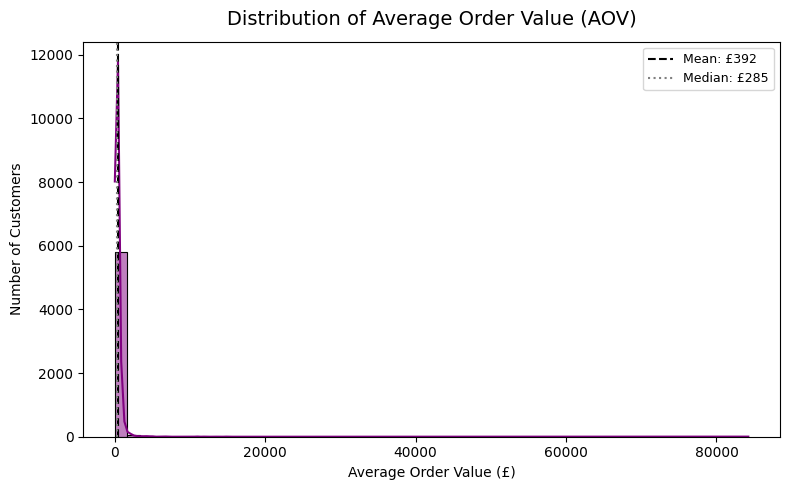

In [24]:
rfm['AOV'] = rfm['Monetary'] / rfm['Frequency']
print("Average Order Value (AOV) descriptive statistics:")
print(rfm['AOV'].describe().round(2).to_string())

plt.figure(figsize=(8, 5))
sns.histplot(rfm['AOV'], bins=50, kde=True, color='purple')
plt.title('Distribution of Average Order Value (AOV)', fontsize=14, pad=12)
plt.xlabel('Average Order Value (£)', fontsize=10)
plt.ylabel('Number of Customers', fontsize=10)
plt.axvline(rfm['AOV'].mean(), color='black', linestyle='--', lw=1.5, label=f'Mean: £{rfm['AOV'].mean():.0f}')
plt.axvline(rfm['AOV'].median(), color='gray',  linestyle=':',  lw=1.5, label=f'Median: £{rfm['AOV'].median():.0f}')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

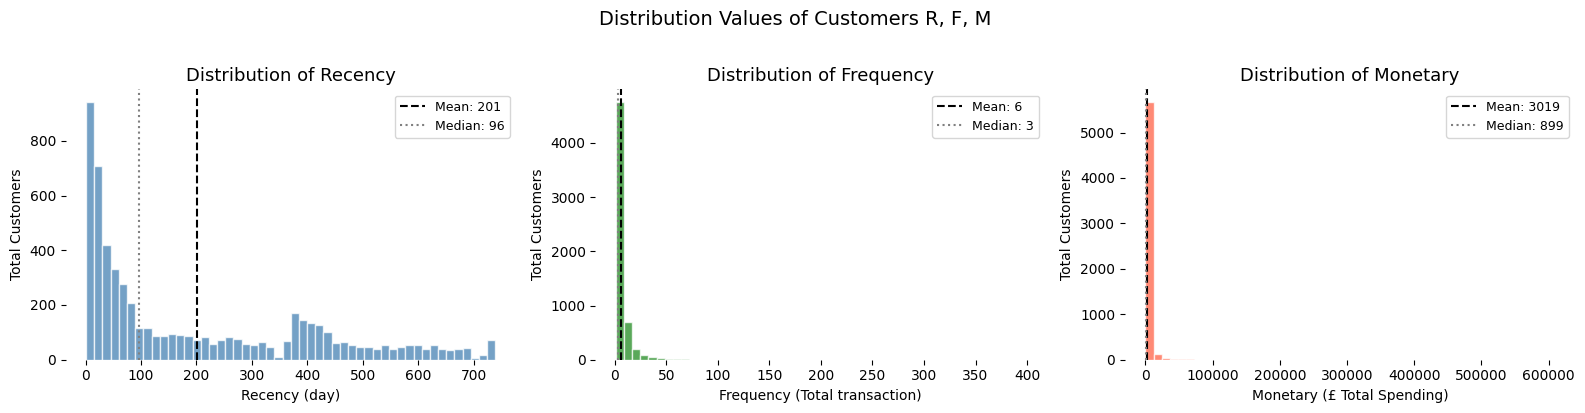

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
configs = [
    ('Recency',   'Recency (day)',              'steelblue'),
    ('Frequency', 'Frequency (Total transaction)','forestgreen'),
    ('Monetary',  'Monetary (£ Total Spending)',    'tomato')]

for ax, (col, xlabel, color) in zip(axes, configs):
    ax.hist(rfm[col], bins=50, color=color, alpha=0.75, edgecolor='white')
    ax.axvline(rfm[col].mean(),   color='black', linestyle='--', lw=1.5, label=f'Mean: {rfm[col].mean():.0f}')
    ax.axvline(rfm[col].median(), color='gray',  linestyle=':',  lw=1.5, label=f'Median: {rfm[col].median():.0f}')
    ax.set_title(f'Distribution of {col}', fontsize=13)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel('Total Customers', fontsize=10)
    ax.legend(fontsize=9)
    ax.set_frame_on(False)
plt.suptitle('Distribution Values of Customers R, F, M', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 7. RFM Scoring (Quintile 1-5)

In [26]:
rfm['R'] = pd.qcut(rfm['Recency'], q=5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm['F'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['M'] = pd.qcut(rfm['Monetary'].rank(method='first'),  q=5, labels=[1, 2, 3, 4, 5]).astype(int)

---
## 8. Customer Segmentation - 11 Segments


In [27]:
def segment_customer(row):
    r, f, m = row['R'], row['F'], row['M']

    if   r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r <= 2 and f >= 4 and m >= 4:
        return 'Cannot Lose Them'
    elif f >= 3 and m >= 3 and r >= 2:
        return 'Loyal Customers'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    elif r == 3 and f >= 2 and m >= 2:
        return 'Need Attention'
    elif r >= 3 and f >= 2 and m >= 2:
        return 'Potential Loyalist'
    elif r >= 4 and f <= 1 and m <= 2:
        return 'New Customers'
    elif r >= 3 and f <= 2 and m <= 2:
        return 'Promising'
    elif r == 2 and f <= 2 and m <= 2:
        return 'About to Sleep'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Hibernating'
    else:
        return 'Lost'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

In [28]:
n_segments = rfm['Segment'].nunique()
print(f"Jumlah segmen terbentuk: {n_segments}")
print(rfm['Segment'].value_counts())

Jumlah segmen terbentuk: 11
Segment
Loyal Customers       1386
Champions             1300
Hibernating            779
Lost                   557
About to Sleep         496
Potential Loyalist     334
Promising              284
Need Attention         228
Cannot Lose Them       227
New Customers          151
At Risk                136
Name: count, dtype: int64


---
## 9. Data Visualization

### 9.1 Distribution by Segments

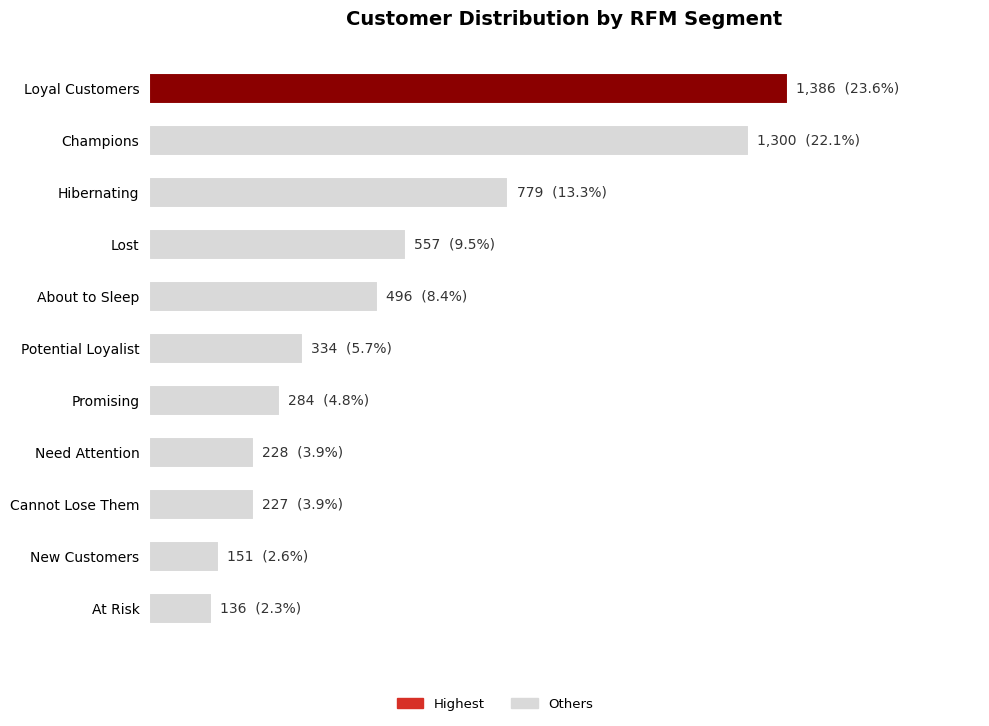

In [29]:
counts = rfm['Segment'].value_counts().sort_values(ascending=True)
total  = counts.sum()
colors = ['#8B0000' if v == counts.max() else '#d9d9d9' for v in counts.values]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(counts.index, counts.values, color=colors, height=0.6, edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_width() + total * 0.003, bar.get_y() + bar.get_height() / 2,
            f'{val:,}  ({val*100/total:.1f}%)',
            va='center', ha='left', fontsize=10, color='#333333')

ax.set_title('Customer Distribution by RFM Segment', fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(0, counts.max() * 1.3)
ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
ax.tick_params(left=False, bottom=False, labelbottom=False, labelleft=True)
ax.set_yticks(range(len(counts.index)))
ax.set_yticklabels(counts.index, fontsize=10)
ax.yaxis.grid(False)
ax.xaxis.grid(False)

fig.legend(handles=[mpatches.Patch(color='#d73027', label='Highest'),
                    mpatches.Patch(color='#d9d9d9', label='Others')], loc='lower center', ncol=2, frameon=False, fontsize=9.5, bbox_to_anchor=(0.5, -0.04))
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig('rfm_segment.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
rfm_reset = rfm.reset_index()
summary = (rfm_reset.groupby('Segment').agg(
        Number_of_Customers = ('Customer ID', 'count'),
        Avg_Recency         = ('Recency',     'mean'),
        Avg_Frequency       = ('Frequency',   'mean'),
        Avg_Monetary        = ('Monetary',    'mean'),
        Total_Revenue       = ('Monetary',    'sum')
        ).round(2)
        .sort_values('Total_Revenue', ascending=False)
        .reset_index()
)

total_cust    = summary['Number_of_Customers'].sum()
total_revenue = summary['Total_Revenue'].sum()
summary['Pct_Customer'] = (summary['Number_of_Customers'] / total_cust    * 100).round(1)
summary['Pct_Revenue']  = (summary['Total_Revenue']   / total_revenue * 100).round(1)

print("=" * 95)
print(f"{'Segment':<22} {'Cust':>6} {'%Cust':>7} {'Avg_R':>7} {'Avg_F':>7} {'Avg_M':>10} {'Total_Rev':>13} {'%Rev':>7}")
print("=" * 95)
for _, row in summary.iterrows():
    print(f"{row['Segment']:<22} {int(row['Number_of_Customers']):>6,} "
          f"{row['Pct_Customer']:>6.1f}% "
          f"{row['Avg_Recency']:>7.0f} "
          f"{row['Avg_Frequency']:>7.1f} "
          f"£{row['Avg_Monetary']:>9,.0f} "
          f"£{row['Total_Revenue']:>12,.0f} "
          f"{row['Pct_Revenue']:>6.1f}%")
print("=" * 95)
print(f"{'TOTAL':<22} {total_cust:>6,} {'100.0%':>7}" + f"{'':>27} £{total_revenue:>12,.0f} {'100.0%':>7}")

Segment                  Cust   %Cust   Avg_R   Avg_F      Avg_M     Total_Rev    %Rev
Champions               1,300   22.1%      20    17.1 £    9,329 £  12,128,116   68.4%
Loyal Customers         1,386   23.6%     116     5.5 £    2,126 £   2,946,906   16.6%
Cannot Lose Them          227    3.9%     341     8.9 £    4,488 £   1,018,867    5.7%
Lost                      557    9.5%     347     2.2 £      886 £     493,713    2.8%
Potential Loyalist        334    5.7%      26     2.4 £    1,156 £     386,028    2.2%
Hibernating               779   13.3%     562     1.1 £      247 £     192,051    1.1%
At Risk                   136    2.3%     486     3.5 £    1,364 £     185,510    1.0%
Need Attention            228    3.9%     111     2.5 £      677 £     154,370    0.9%
About to Sleep            496    8.4%     320     1.2 £      273 £     135,592    0.8%
Promising                 284    4.8%      89     1.2 £      228 £      64,723    0.4%
New Customers             151    2.6%      

### 9.2 Revenue by Segments

/tmp/ipykernel_2259/1141599641.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(d['Segment'], fontsize=10)
/tmp/ipykernel_2259/1141599641.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(d['Segment'], fontsize=10)


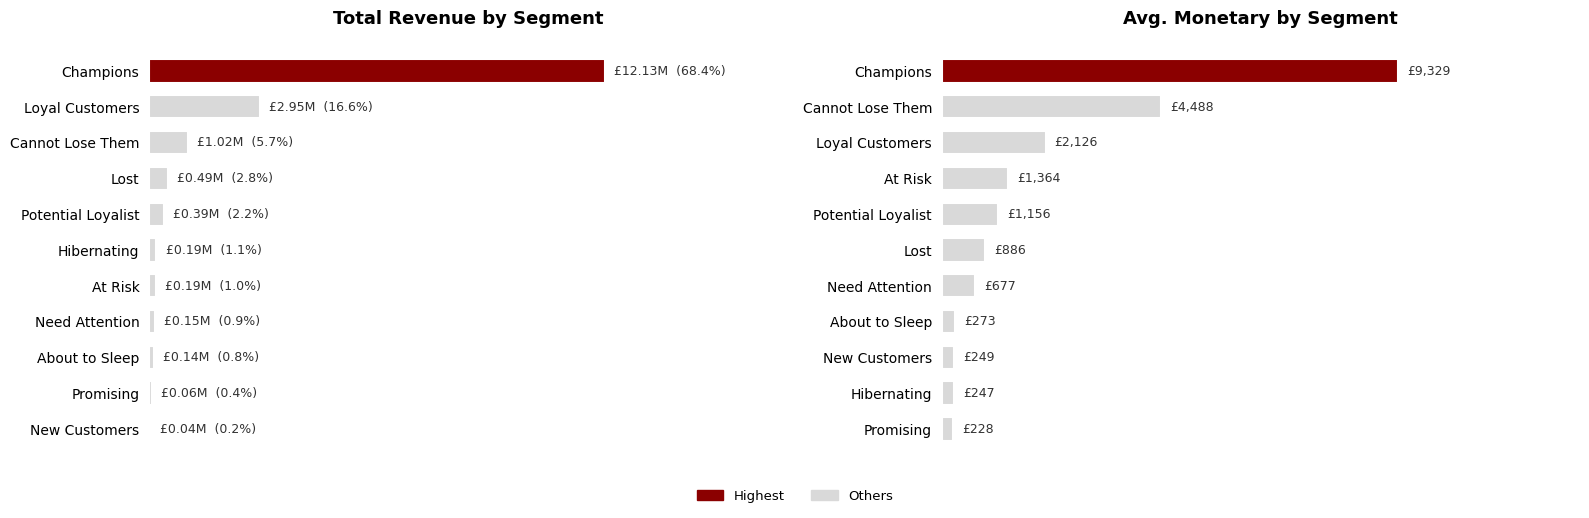

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_visible(False)

def make_chart(ax, data, col, title, label_fn):
    d = data.sort_values(col, ascending=True)
    colors = ['#8B0000' if v == d[col].max() else '#d9d9d9' for v in d[col]]
    bars = ax.barh(d['Segment'], d[col], color=colors, height=0.65, edgecolor='white', linewidth=1.5)

    for bar, val in zip(bars, d[col]):
        ax.text(bar.get_width() + d[col].max() * 0.02,
                bar.get_y() + bar.get_height() / 2,
                label_fn(val), va='center', ha='left',
                fontsize=9, color='#333333')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    ax.set_xlim(0, d[col].max() * 1.4)
    ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
    ax.tick_params(left=False, bottom=False, labelbottom=False)
    ax.set_yticklabels(d['Segment'], fontsize=10)
    ax.set_facecolor('none')
    ax.grid(False)

make_chart(axes[0], summary, 'Total_Revenue', 'Total Revenue by Segment',
           lambda v: f'£{v/1e6:.2f}M  ({v*100/summary["Total_Revenue"].sum():.1f}%)')
make_chart(axes[1], summary, 'Avg_Monetary', 'Avg. Monetary by Segment',
           lambda v: f'£{v:,.0f}')

fig.legend(handles=[mpatches.Patch(color='#8B0000', label='Highest'),
                    mpatches.Patch(color='#d9d9d9', label='Others')],
                    loc='lower center', ncol=2, frameon=False, fontsize=9.5, bbox_to_anchor=(0.5, -0.04))
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig('rfm_revenue.png', dpi=150, bbox_inches='tight', transparent=True)
plt.show()

/tmp/ipykernel_2259/560886080.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(df_plot['Segment'], fontsize=10)


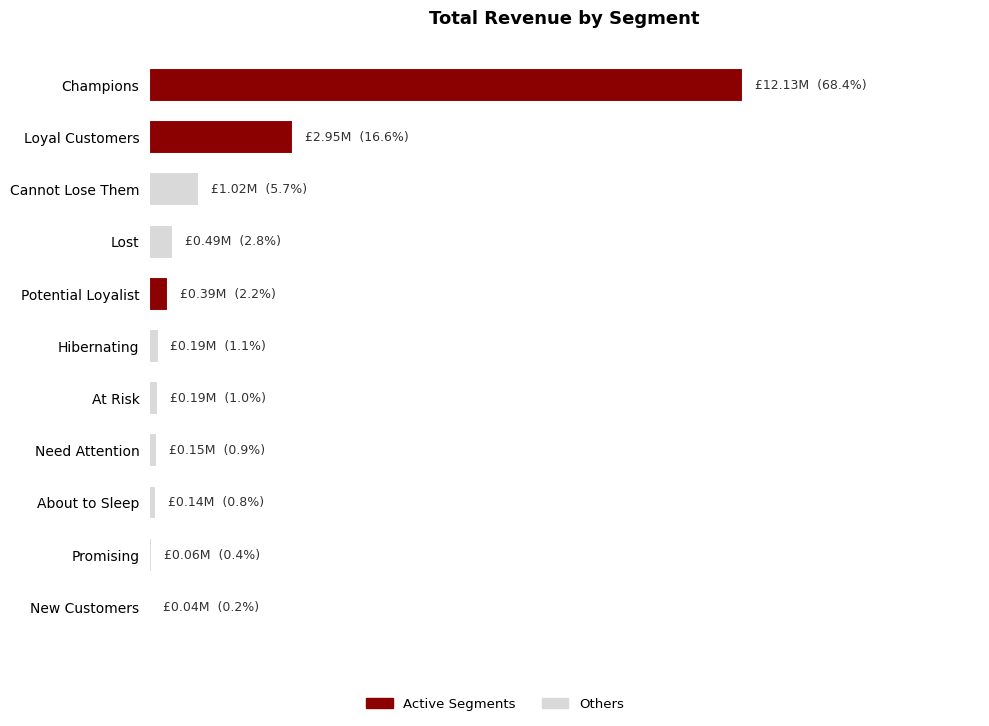

In [32]:
fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_visible(False)

df_plot = summary.sort_values('Total_Revenue', ascending=True)

highlight_segments = ['Champions', 'Loyal Customers', 'Potential Loyalist']
colors = ['#8B0000' if s in highlight_segments else '#d9d9d9' for s in df_plot['Segment']]

bars = ax.barh(df_plot['Segment'], df_plot['Total_Revenue'], color=colors, height=0.65, edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, df_plot['Total_Revenue']):
    ax.text(bar.get_width() + df_plot['Total_Revenue'].max() * 0.02,
            bar.get_y() + bar.get_height() / 2,
            f'£{val/1e6:.2f}M  ({val*100/summary["Total_Revenue"].sum():.1f}%)', va='center', ha='left',
            fontsize=9, color='#333333')

ax.set_title('Total Revenue by Segment', fontsize=13, fontweight='bold', pad=12)
ax.set_xlim(0, df_plot['Total_Revenue'].max() * 1.4)
ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
ax.tick_params(left=False, bottom=False, labelbottom=False)
ax.set_yticklabels(df_plot['Segment'], fontsize=10)
ax.set_facecolor('none')
ax.grid(False)

fig.legend(handles=[mpatches.Patch(color='#8B0000', label='Active Segments'),
                    mpatches.Patch(color='#d9d9d9', label='Others')],
                    loc='lower center', ncol=2, frameon=False, fontsize=9.5, bbox_to_anchor=(0.5, -0.04))
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

### 9.3 Treemap - Customer's Proportion by Segments

In [33]:
color_map = {
    'Champions':          '#8B1A1A',
    'Loyal Customers':    '#E8861A',
    'Need Attention':     '#F4A636',
    'Promising':          '#1ABC9C',
    'About to Sleep':     '#95A5A6',
    'Hibernating':        '#7F8C8D',
    'Potential Loyalist': '#5DADE2',
    'Lost':               '#BDC3C7',
    'New Customers':      '#E67E22',
    'At Risk':            '#E74C3C',
    'Cannot Lose Them':   '#9B59B6',
}

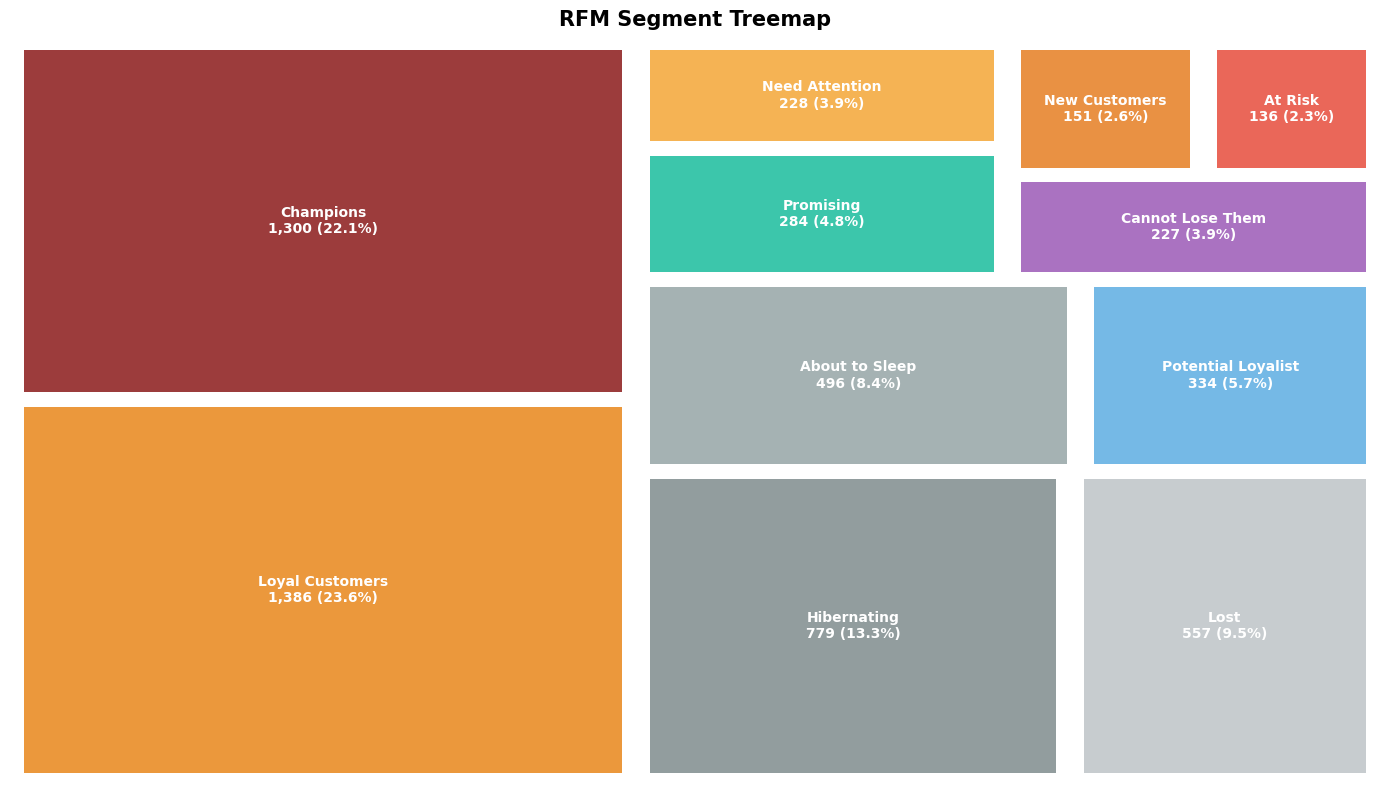

In [34]:
tree_data   = summary.sort_values('Number_of_Customers', ascending=False)
sizes       = tree_data['Number_of_Customers'].tolist()
tree_labels = tree_data.apply(
    lambda x: f"{x['Segment']}\n{int(x['Number_of_Customers']):,} ({x['Pct_Customer']:.1f}%)"
, axis=1).tolist()

tree_colors = [color_map.get(s, '#BDC3C7') for s in tree_data['Segment']]

plt.figure(figsize=(14, 8))
squarify.plot(sizes=sizes, label=tree_labels, color=tree_colors,
              alpha=0.85, pad=True, text_kwargs={'fontsize': 10, 'color': 'white', 'fontweight': 'bold'})
plt.title('RFM Segment Treemap', fontsize=15, fontweight='bold', pad=12)
plt.axis('off')
plt.tight_layout()
plt.show()

### 9.4 Product Price Mix by RFM Segments


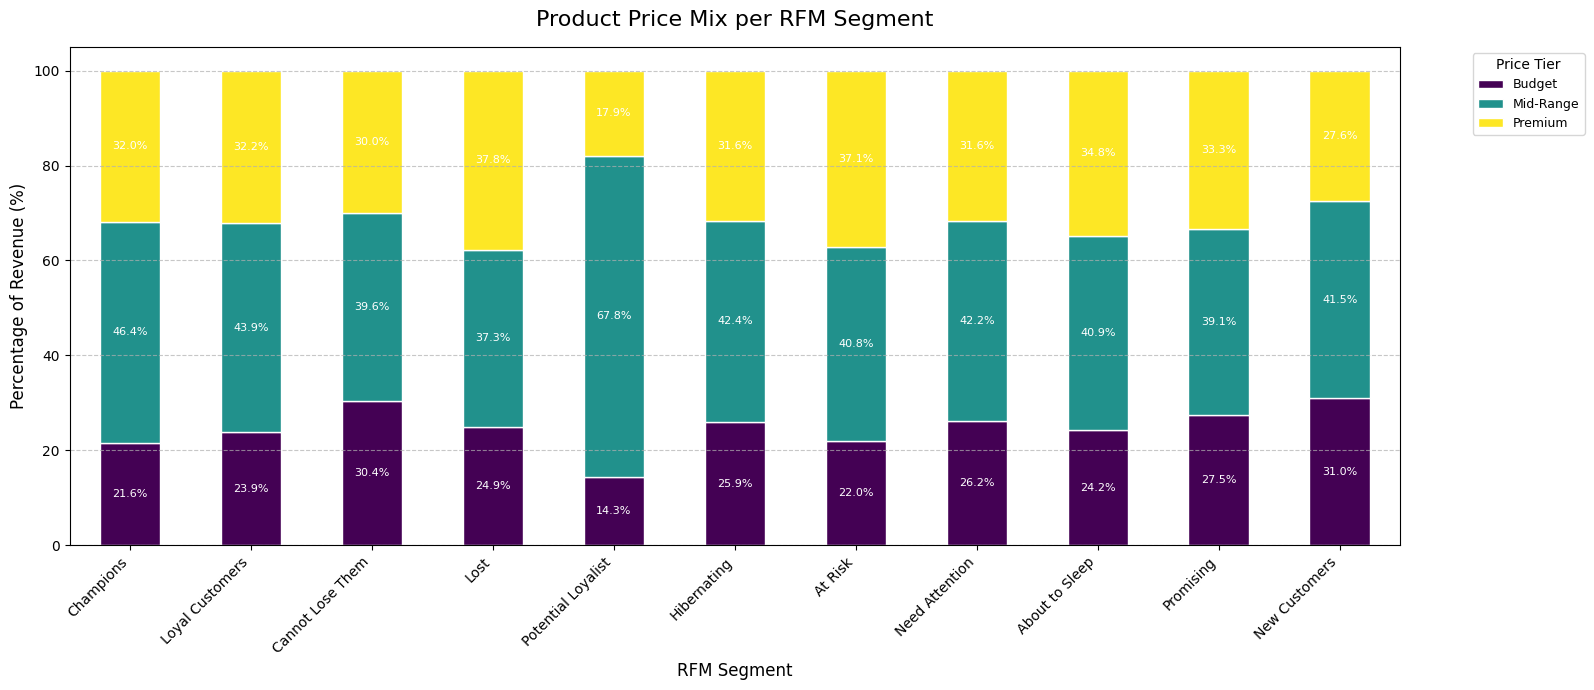

In [35]:
price_quantiles = df['Price'].quantile([0.25, 0.75])
low_threshold = price_quantiles[0.25]
high_threshold = price_quantiles[0.75]

def categorize_price_tier(price):
    if price <= low_threshold:
        return 'Budget'
    elif price <= high_threshold:
        return 'Mid-Range'
    else:
        return 'Premium'

df['PriceTier'] = df['Price'].apply(categorize_price_tier)
df_segment_pricetier = df.merge(rfm.reset_index()[['Customer ID', 'Segment']], on='Customer ID', how='left')
pricetier_mix_per_segment = df_segment_pricetier.groupby(['Segment', 'PriceTier'])['TotalPrice'].sum().reset_index()
pricetier_mix_per_segment['Percentage'] = pricetier_mix_per_segment.groupby('Segment')['TotalPrice'].transform(lambda x: (x / x.sum()) * 100)
segment_order = summary['Segment'].tolist()
pricetier_mix_per_segment['Segment'] = pd.Categorical(pricetier_mix_per_segment['Segment'], categories=segment_order, ordered=True)
pricetier_mix_per_segment = pricetier_mix_per_segment.sort_values(['Segment', 'Percentage'], ascending=[True, False])
pricetier_mix_pivot = pricetier_mix_per_segment.pivot(index='Segment', columns='PriceTier', values='Percentage').fillna(0)
price_tier_order = ['Budget', 'Mid-Range', 'Premium']
pricetier_mix_pivot = pricetier_mix_pivot.reindex(columns=price_tier_order, fill_value=0)

ax = pricetier_mix_pivot.plot(
    kind='bar',
    stacked=True,
    figsize=(16, 7),
    cmap='viridis',
    edgecolor='white'
)

for container in ax.containers:
    labels = [f'{w:.1f}%' if (w := v.get_height()) > 0 else '' for v in container]
    ax.bar_label(container, labels=labels, label_type='center', color='white', fontsize=8)

ax.set_title('Product Price Mix per RFM Segment', fontsize=16, pad=15)
ax.set_xlabel('RFM Segment', fontsize=12)
ax.set_ylabel('Percentage of Revenue (%)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
ax.legend(title='Price Tier', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 9.5 Average of Dimentions

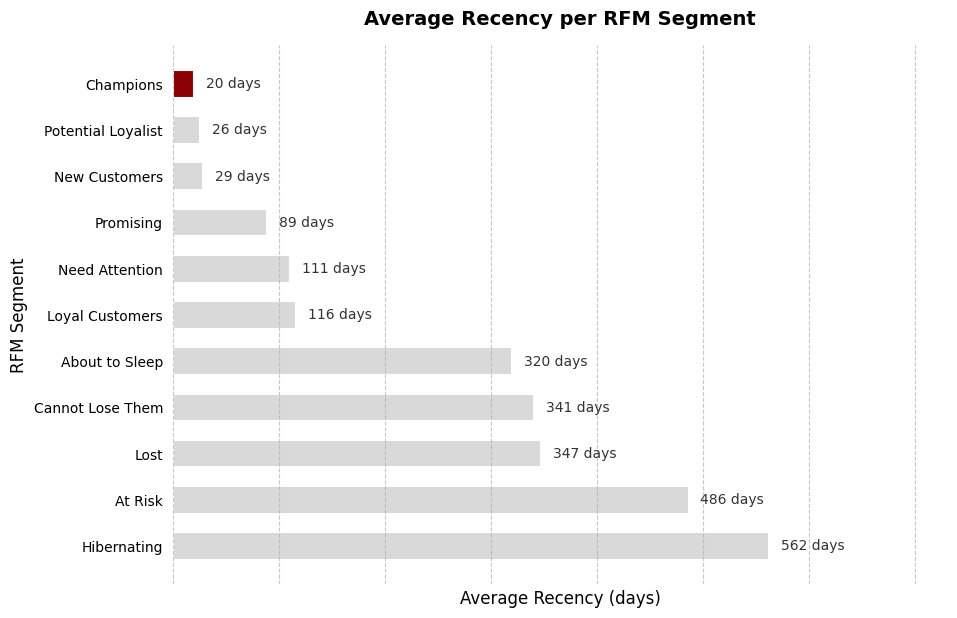

In [36]:
plt.figure(figsize=(10, 7))
df_plot = summary.sort_values('Avg_Recency', ascending=False)
min_recency = df_plot['Avg_Recency'].min()
colors = ['#8B0000' if val == min_recency else '#d9d9d9' for val in df_plot['Avg_Recency']]
bars = plt.barh(df_plot['Segment'], df_plot['Avg_Recency'], color=colors, height=0.6, edgecolor='white', linewidth=1.5)

for bar in bars:
    plt.text(bar.get_width() + df_plot['Avg_Recency'].max() * 0.02,
             bar.get_y() + bar.get_height() / 2,
             f'{bar.get_width():.0f} days',
             va='center', ha='left', fontsize=10, color='#333333')

plt.title('Average Recency per RFM Segment', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Average Recency (days)', fontsize=12)
plt.ylabel('RFM Segment', fontsize=12)
plt.xlim(0, df_plot['Avg_Recency'].max() * 1.3)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.gca().spines[['top', 'right', 'left', 'bottom']].set_visible(False)
plt.tick_params(left=False, bottom=False, labelbottom=False)
plt.show()

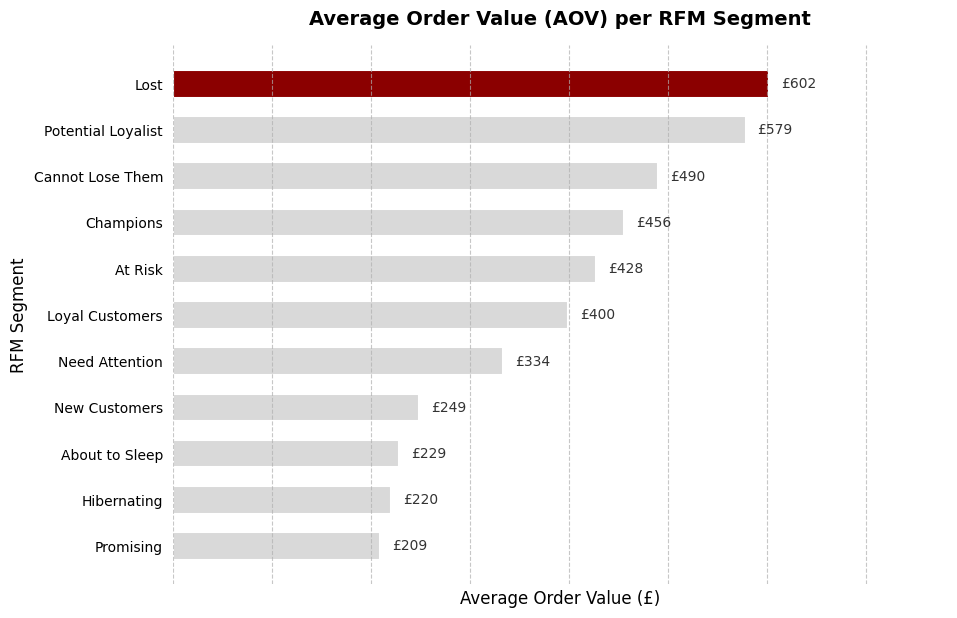

In [37]:
aov_per_segment = rfm.groupby('Segment')['AOV'].mean().reset_index()
aov_per_segment.rename(columns={'AOV': 'Avg_AOV'}, inplace=True)

plt.figure(figsize=(10, 7))
df_plot = aov_per_segment.sort_values('Avg_AOV', ascending=True)
max_aov = df_plot['Avg_AOV'].max()
colors = ['#8B0000' if val == max_aov else '#d9d9d9' for val in df_plot['Avg_AOV']]
bars = plt.barh(df_plot['Segment'], df_plot['Avg_AOV'], color=colors, height=0.6, edgecolor='white', linewidth=1.5)

for bar in bars:
    plt.text(bar.get_width() + df_plot['Avg_AOV'].max() * 0.02,
             bar.get_y() + bar.get_height() / 2,
             f'£{bar.get_width():.0f}',
             va='center', ha='left', fontsize=10, color='#333333')

plt.title('Average Order Value (AOV) per RFM Segment', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Average Order Value (£)', fontsize=12)
plt.ylabel('RFM Segment', fontsize=12)
plt.xlim(0, df_plot['Avg_AOV'].max() * 1.3)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.gca().spines[['top', 'right', 'left', 'bottom']].set_visible(False)
plt.tick_params(left=False, bottom=False, labelbottom=False)
plt.show()

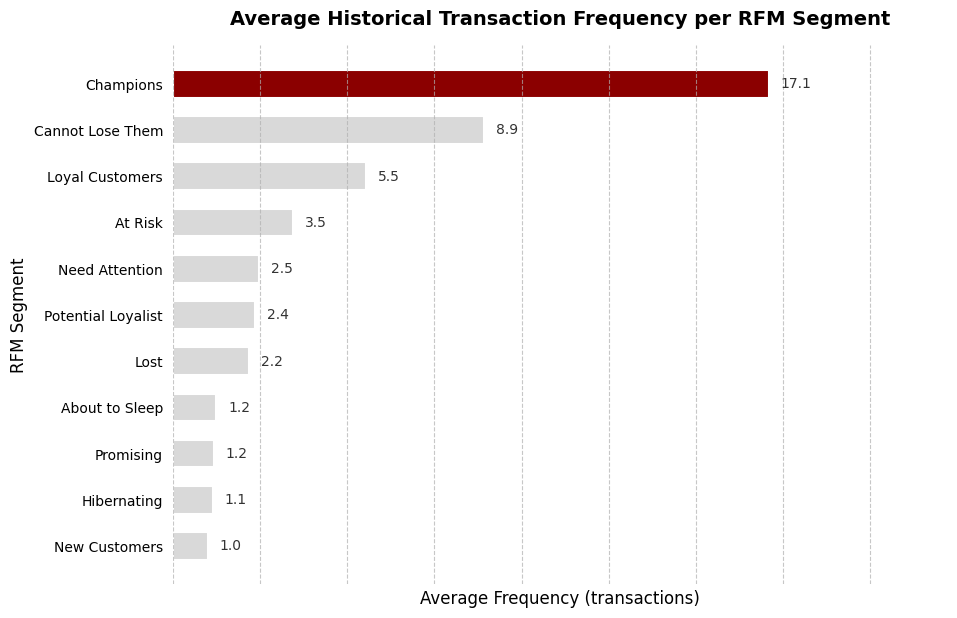

In [38]:
plt.figure(figsize=(10, 7))
df_plot = summary.sort_values('Avg_Frequency', ascending=True)
max_freq = df_plot['Avg_Frequency'].max()
colors = ['#8B0000' if val == max_freq else '#d9d9d9' for val in df_plot['Avg_Frequency']]
bars = plt.barh(df_plot['Segment'], df_plot['Avg_Frequency'], color=colors, height=0.6, edgecolor='white', linewidth=1.5)

for bar in bars:
    plt.text(bar.get_width() + df_plot['Avg_Frequency'].max() * 0.02,
             bar.get_y() + bar.get_height() / 2,
             f'{bar.get_width():.1f}',
             va='center', ha='left', fontsize=10, color='#333333')

plt.title('Average Historical Transaction Frequency per RFM Segment', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Average Frequency (transactions)', fontsize=12)
plt.ylabel('RFM Segment', fontsize=12)
plt.xlim(0, df_plot['Avg_Frequency'].max() * 1.3) # Adjust x-limit for labels
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.gca().spines[['top', 'right', 'left', 'bottom']].set_visible(False)
plt.tick_params(left=False, bottom=False, labelbottom=False)
plt.show()

### 9.6 Top 10 Products

/tmp/ipykernel_2259/2336458488.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='TotalPrice', y='Description', data=top_N_last_products, palette='viridis')


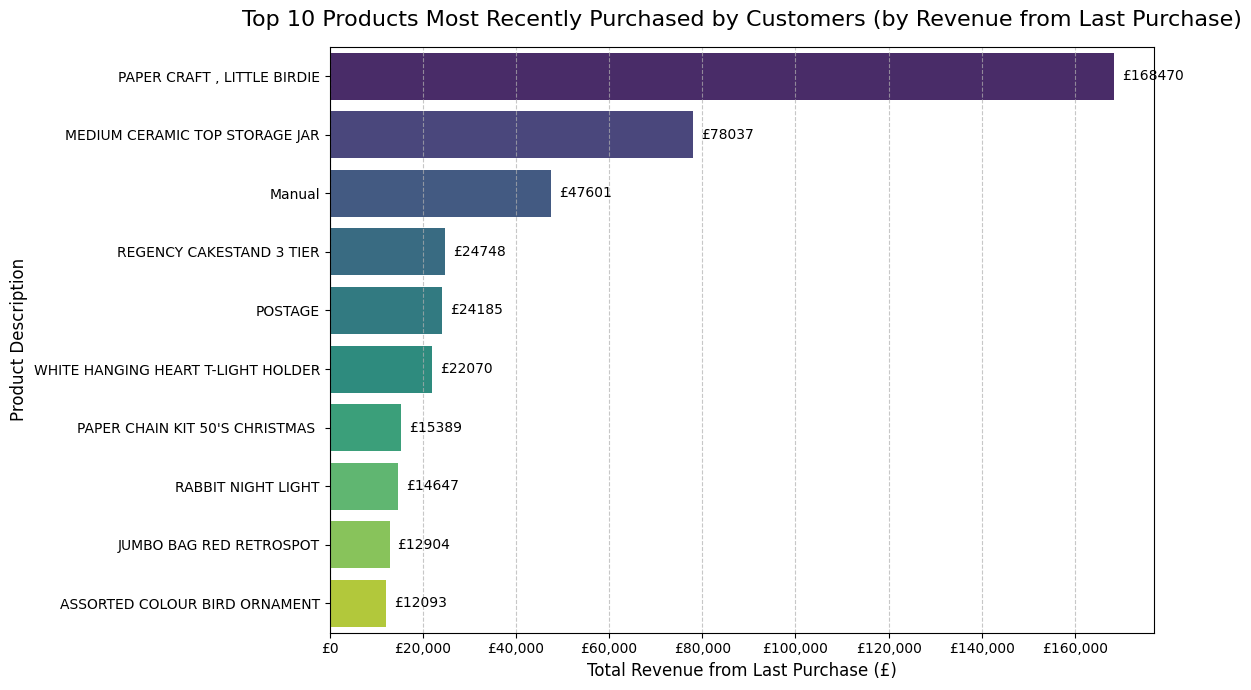

In [39]:
last_purchase_date = df.groupby('Customer ID')['InvoiceDate'].max().reset_index()
last_purchase_date.rename(columns={'InvoiceDate': 'LastPurchaseDate'}, inplace=True)
df_last_purchase_items = df.merge(last_purchase_date[['Customer ID', 'LastPurchaseDate']], on='Customer ID', how='left')
last_bought_items_only = df_last_purchase_items[df_last_purchase_items['InvoiceDate'] == df_last_purchase_items['LastPurchaseDate']].copy() # Use .copy() to avoid SettingWithCopyWarning

N = 10
top_N_last_products = last_bought_items_only.groupby('Description')['TotalPrice'].sum().nlargest(N).reset_index()

plt.figure(figsize=(12, 7))
sns.barplot(x='TotalPrice', y='Description', data=top_N_last_products, palette='viridis')
plt.title(f'Top {N} Products Most Recently Purchased by Customers (by Revenue from Last Purchase)', fontsize=16, pad=15)
plt.xlabel('Total Revenue from Last Purchase (£)', fontsize=12)
plt.ylabel('Product Description', fontsize=12)
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.grid(axis='x', linestyle='--', alpha=0.7)

for index, row in top_N_last_products.iterrows():
    plt.text(row['TotalPrice'] + (top_N_last_products['TotalPrice'].max() * 0.01), # Position text slightly outside bar
             index,
             f'£{row['TotalPrice']:.0f}',
             va='center', ha='left', color='black', fontsize=10)

plt.tight_layout()
plt.show()

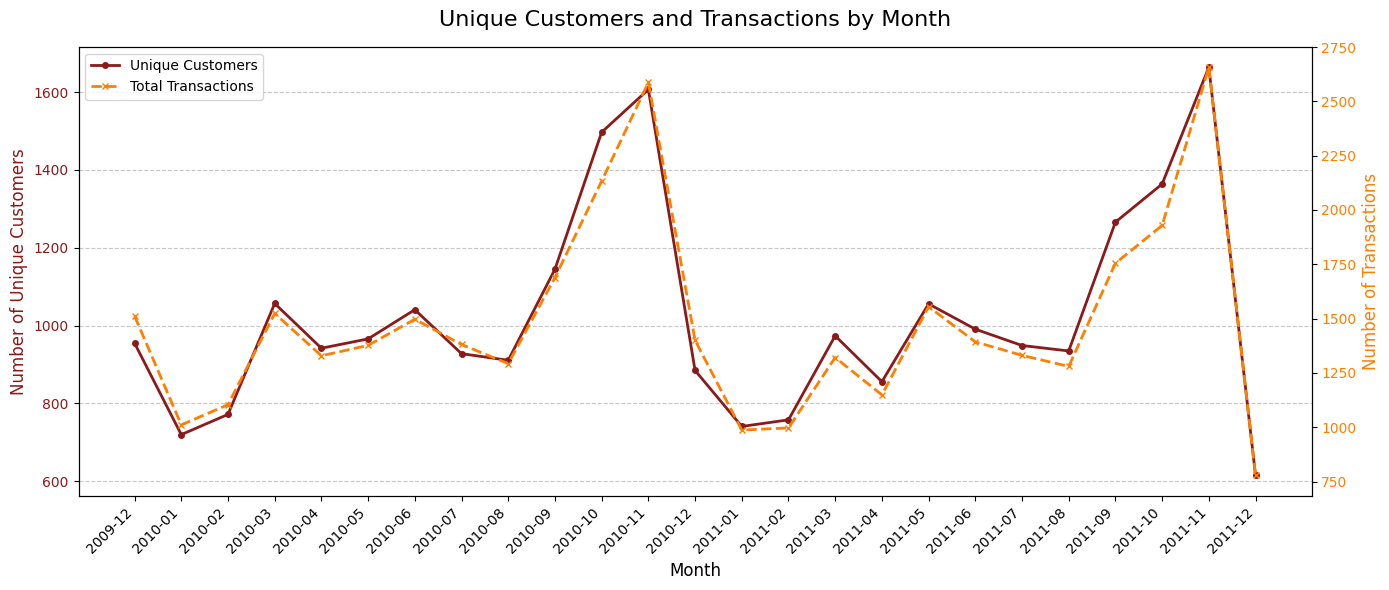

In [40]:
monthly_unique_customers = (df.assign(InvoiceMonth=df['InvoiceDate'].dt.to_period('M')).groupby('InvoiceMonth')['Customer ID'].nunique().reset_index())
monthly_unique_customers['InvoiceMonth'] = monthly_unique_customers['InvoiceMonth'].astype(str)
monthly_transactions = (df.assign(InvoiceMonth=df['InvoiceDate'].dt.to_period('M')).groupby('InvoiceMonth')['Invoice'].nunique().reset_index())
monthly_transactions['InvoiceMonth'] = monthly_transactions['InvoiceMonth'].astype(str)
monthly_transactions.rename(columns={'Invoice': 'TotalTransactions'}, inplace=True)
monthly_data = pd.merge(monthly_unique_customers, monthly_transactions, on='InvoiceMonth')

fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(
    monthly_data['InvoiceMonth'],
    monthly_data['Customer ID'],
    marker='o',
    linestyle='-',
    color='#8b1a1a',
    linewidth=2,
    markersize=4,
    label='Unique Customers'
)
ax1.set_xlabel('Month', fontsize=12)
ax1.set_ylabel('Number of Unique Customers', color='#8b1a1a', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#8b1a1a')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

ax2 = ax1.twinx()
ax2.plot(
    monthly_data['InvoiceMonth'],
    monthly_data['TotalTransactions'],
    marker='x',
    linestyle='--',
    color='#FF7F00',
    linewidth=2,
    markersize=4,
    label='Total Transactions'
)
ax2.set_ylabel('Number of Transactions', color='#FF7F00', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#FF7F00')

plt.title('Unique Customers and Transactions by Month', fontsize=16, pad=15)
ax1.set_xticks(range(len(monthly_data['InvoiceMonth'])))
ax1.set_xticklabels(monthly_data['InvoiceMonth'], rotation=45, ha='right', fontsize=10)

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.show()